# Fine-tuning for classification

## Download and clean dataset

In [53]:
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "sms_spam_collection.tsv"

def download_and_unzip_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download")
        return

    with urllib.request.urlopen(url) as response:
        with open(zip_path, 'wb') as f:
            f.write(response.read())
    
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extracted_path)
    
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"Data downloaded and save as {data_file_path}!")

download_and_unzip_data(url, zip_path, extracted_path, data_file_path)

sms_spam_collection/sms_spam_collection.tsv already exists. Skipping download


In [54]:
import pandas as pd
df = pd.read_csv(data_file_path, sep='\t', header = None, names=['Label', 'Text'])
df


,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [55]:
print(df.value_counts(df["Label"]))

Label
ham     4825
spam     747
Name: count, dtype: int64


In [56]:
def create_balanced_dataset(df):
    num_spam = df[df['Label'] == 'spam'].shape[0]
    ham_subset = df[df['Label'] == 'ham'].sample(num_spam, random_state=123)
    balanced_df = pd.concat([ham_subset, df[df['Label'] == 'spam']])

    return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df.value_counts(df['Label']))

Label
ham     747
spam    747
Name: count, dtype: int64


In [57]:
balanced_df['Label'] = balanced_df['Label'].map({'ham': 0, 'spam': 1})
balanced_df

,Label,Text
4307,0,Awww dat is sweet! We can think of something t...
4138,0,Just got to &lt;#&gt;
4831,0,"The word ""Checkmate"" in chess comes from the P..."
4461,0,This is wishing you a great day. Moji told me ...
5440,0,Thank you. do you generally date the brothas?
...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,1,Had your contract mobile 11 Mnths? Latest Moto...
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...


In [58]:
def random_split(df,train_frac, validation_frac):
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)
    train_end = int(len(df) * train_frac)
    val_end = train_end + int(len(df) * validation_frac)

    train_df = df[:train_end]
    val_df = df[train_end:val_end]
    test_df = df[val_end:]

    return train_df, val_df, test_df

train_df, val_df, test_df = random_split(balanced_df, 0.7, 0.1)

In [59]:
train_df.to_csv("train.csv", index=None)
test_df.to_csv("test.csv", index=None)
val_df.to_csv("val.csv", index=None)

## Create Dataloader

In [60]:
import tiktoken
tokenizer = tiktoken.get_encoding('gpt2')
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [61]:
import torch
from torch.utils.data import Dataset, DataLoader

class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256): # 50256 = <|endoftext|>
        self.data = pd.read_csv(csv_file)
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data['Text']
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            self.encoded_texts = [
                encoded_text[:max_length] for encoded_text in self.encoded_texts
            ]

        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text)) for encoded_text in self.encoded_texts
        ]
        
    def __getitem__(self, index):
        encoded_text = torch.tensor(
            self.encoded_texts[index],
            dtype=torch.long
        )

        label = torch.tensor(
            self.data.iloc[index]['Label'],
            dtype=torch.long
        )

        return (encoded_text, label)
    
    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_text_len = len(encoded_text)
            if  encoded_text_len> max_length:
                max_length = encoded_text_len
        return max_length
    
train_dataset = SpamDataset('train.csv', tokenizer)
test_dataset = SpamDataset('test.csv', tokenizer)
val_dataset = SpamDataset('val.csv', tokenizer)

In [62]:
num_workers = 0
batch_size = 8
torch.manual_seed(123)

train_loader = DataLoader(train_dataset, batch_size, shuffle=True, num_workers=num_workers, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size, shuffle=False, num_workers=num_workers, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size, shuffle=False, num_workers=num_workers, drop_last=False)


In [63]:
for input, output in val_loader:
    print("input: ", input)
    print("output: ", output)

input:  tensor([[   44, 10102,    11,  2479,  1954,    11, 21541,    11,   649,   287,
          3482,    13,   314,   804,  1714,   351,  3482,  3730,    13,   611,
           334,   588,  1257,   351,   502,    13,  8255, 19308, 28082,   284,
         39861,  2791,    13,  1507,   764,  1542,   381,    14, 14116,   352,
           301,   642,  5787,    13,  4248,    16,    13,  1120, 41867,    13,
         10478,  2919,    22, 23451, 25270,  4304, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256],
        [39505,   563,  5650,  3730,  4203, 14720,   290,   510,   604,   340,
            11,   783,    13,  4889,   657,  5774, 23451,  1270, 31046,   655,
           838,    79,    14,  1084,    13,  1675,  2245, 13399,   869,   657,
          5774, 17464,  1899, 33916,   357,   940,    79,    14,  1084,     8,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 5025

## Load pretrain GPT2 model

In [64]:
import sys
sys.path.append(str(Path("..").resolve())) # result parent folder
from miniGPT.model import GPT2
from tools.gpt_download import download_and_load_gpt2

setting, params = download_and_load_gpt2(model_size="124M", models_dir='../gpt2')

# config from GPT2 model
model_config = {
    "vocab_size": 50257,
    "context_length": 1024,
    "embedding_dim": 768,
    "num_heads": 12,
    "num_layers": 12,
    "dropout": 0.1,
    "qkv_bias": True, # OPENAI CONFIG
}
model = GPT2(model_config)
model.load_pretrain_weights(params)

File already exists and is up-to-date: ../gpt2/124M/checkpoint
File already exists and is up-to-date: ../gpt2/124M/encoder.json
File already exists and is up-to-date: ../gpt2/124M/hparams.json
File already exists and is up-to-date: ../gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: ../gpt2/124M/model.ckpt.index
File already exists and is up-to-date: ../gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: ../gpt2/124M/vocab.bpe
initializing multi head attention with d_in: 768 d_out: 768 num_heads: 12 context_length: 1024 dropout: 0.1
initializing multi head attention with d_in: 768 d_out: 768 num_heads: 12 context_length: 1024 dropout: 0.1
initializing multi head attention with d_in: 768 d_out: 768 num_heads: 12 context_length: 1024 dropout: 0.1
initializing multi head attention with d_in: 768 d_out: 768 num_heads: 12 context_length: 1024 dropout: 0.1
initializing multi head attention with d_in: 768 d_out: 768 num_heads: 12 context_length: 102

In [65]:
# test without finetune is the model can answers my question
question = ("Is the following text 'spam'? Answer with 'yes' or 'no': "
            "'you are a winner you have been specially"
            "selected to receive $1000 cash or a $2000 award.")

print(model.generate(question, 23, context_size=model_config['context_length']))

Is the following text 'spam'? Answer with 'yes' or 'no': 'you are a winner you have been speciallyselected to receive $1000 cash or a $2000 award.

'you are a winner you have been specially selected to receive $1000 cash or a $2000 award.


In [77]:
print(model)
for params in model.parameters():
    params.requires_grad = False

GPT2(
  (token_embedding): Embedding(50257, 768)
  (position_embedding): Embedding(1024, 768)
  (dropout_embedding): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): Transformer(
      (attention): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (Dropout): Dropout(p=0.1, inplace=False)
        (OutProj): Linear(in_features=768, out_features=768, bias=True)
      )
      (feed_forward): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): Transformer(
      (attention): Mult

In [78]:
import torch.nn as nn
num_classes = 2 # spam or not spam
model.output_head = nn.Linear(model_config['embedding_dim'], num_classes)

for param in model.final_norm.parameters():
    param.requires_grad = True

for param in model.transformer_blocks[-1].parameters():
    param.requires_grad = True

In [84]:
def calc_accuracy_loader(dataloader, model, device, num_batches = None):
    model.eval()
    correct_predictions, num_examples = 0,0

    if num_batches is None:
        num_batches = len(dataloader)
    else:
        num_batches = min(num_batches, len(dataloader))
    
    for i, (input_batch, target_batch) in enumerate(dataloader):
        # print('input_batch: ', input_batch)
        # print('target_batch: ', target_batch)
        if i < num_batches:
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)

            with torch.no_grad():
                logits = model(input_batch)[:,-1,:]
                # print("logits: ", logits)

            predicted_label = torch.argmax(logits, dim=-1)
            num_examples += predicted_label.shape[0]
            correct_predictions += (predicted_label == target_batch).sum().item()

        else:
            break

    return correct_predictions / num_examples


    

In [85]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

torch.manual_seed(123)

train_accuracy = calc_accuracy_loader(train_loader, model, device, 10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, 10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, 10)

print("train_accuracy: ", train_accuracy)
print("test_accuracy: ", test_accuracy)
print("val_accuracy: ", val_accuracy)


train_accuracy:  0.5375
test_accuracy:  0.5125
val_accuracy:  0.55


In [86]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)

    logits = model(input_batch)[:,-1,:]
    loss = torch.nn.functional.cross_entropy(logits, target_batch)

    return loss

def calc_loss_dataloader(dataloader, model, device, num_batches=None):
    if num_batches is None:
        num_batches = len(dataloader)
    else:
        num_batches = min(num_batches, len(dataloader))

    if len(dataloader) ==0:
        return float('nan')
    
    total_loss =0.
    for i, (input_batch, target_batch) in enumerate(dataloader):
        if i < num_batches:
            total_loss += calc_loss_batch(input_batch, target_batch, model, device).item()
        else:
            break
    
    return total_loss / num_batches


In [87]:
with torch.no_grad():
    train_loss = calc_loss_dataloader(train_loader, model, device, 5)

print("train_loss: ", train_loss)

train_loss:  1.2692782998085022


In [91]:
# training loop
def train_classifier(model, train_loader, val_loader, optimizer, device, num_epoches, eval_freq, eval_iter):
    train_losses, val_losses, train_accs, val_accs = [],[],[],[]
    example_seens, global_step = 0, -1

    for epoch in range(num_epoches):
        model.train()
        for i, (input_batch, target_batch) in enumerate(train_loader): 
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()

            optimizer.step()
            example_seens += input_batch.shape[0]
            global_step += 1

            if (global_step % eval_freq == 0):
                train_loss, val_loss = eval_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Epoch: {epoch + 1} (Step: {global_step}): Train loss: {train_loss:3f}, Val loss: {val_loss:3f}")

        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)
        print(f"Epoch {epoch + 1}: Train accuracy: {train_accuracy*100:.2f}, Validate accuracy: {val_accuracy*100:.2f}")
    
    return train_losses, val_losses, train_accs, val_accs, example_seens



def eval_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_dataloader(train_loader, model, device, eval_iter)
        val_loss = calc_loss_dataloader(val_loader, model, device, eval_iter)
    model.train()

    return train_loss, val_loss

In [92]:
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)
train_losses, val_losses, train_accs, val_accs, example_seens = train_classifier(model, train_loader, val_loader, optimizer, device, num_epoches=10, eval_freq=50, eval_iter=5)


Epoch: 1 (Step: 0): Train loss: 0.034096, Val loss: 0.333990
Epoch: 1 (Step: 50): Train loss: 0.034912, Val loss: 0.123687
Epoch: 1 (Step: 100): Train loss: 0.016069, Val loss: 0.145487
Epoch 1: Train accuracy: 95.00, Validate accuracy: 92.50
Epoch: 2 (Step: 150): Train loss: 0.024513, Val loss: 0.162420
Epoch: 2 (Step: 200): Train loss: 0.046677, Val loss: 0.231654
Epoch: 2 (Step: 250): Train loss: 0.053762, Val loss: 0.052348
Epoch 2: Train accuracy: 100.00, Validate accuracy: 95.00
Epoch: 3 (Step: 300): Train loss: 0.017131, Val loss: 0.100616
Epoch: 3 (Step: 350): Train loss: 0.025661, Val loss: 0.070255
Epoch 3: Train accuracy: 97.50, Validate accuracy: 97.50
Epoch: 4 (Step: 400): Train loss: 0.095361, Val loss: 0.019079
Epoch: 4 (Step: 450): Train loss: 0.052359, Val loss: 0.033617
Epoch: 4 (Step: 500): Train loss: 0.063024, Val loss: 0.125496
Epoch 4: Train accuracy: 100.00, Validate accuracy: 97.50
Epoch: 5 (Step: 550): Train loss: 0.003110, Val loss: 0.096921
Epoch: 5 (Step: 6

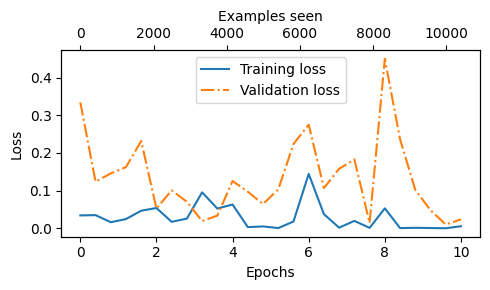

In [93]:
import matplotlib.pyplot as plt

num_epochs  = 10
def plot_values(
        epochs_seen, examples_seen, train_values, val_values,
        label="loss"):

    fig, ax1 = plt.subplots(figsize=(5, 3))

    # 1
    ax1.plot(
        epochs_seen,
        train_values,
        label=f"Training {label}"
    )

    ax1.plot(
        epochs_seen,
        val_values,
        linestyle="-.",
        label=f"Validation {label}"
    )

    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # 2
    ax2 = ax1.twiny()

    ax2.plot(
        examples_seen,
        train_values,
        alpha=0
    )  # 3

    ax2.set_xlabel("Examples seen")

    fig.tight_layout()  # 4

    plt.savefig(f"{label}-plot.pdf")
    plt.show()


epochs_tensor = torch.linspace(
    0,
    num_epochs,
    len(train_losses)
)

examples_seen_tensor = torch.linspace(
    0,
    example_seens,
    len(train_losses)
)

plot_values(
    epochs_tensor,
    examples_seen_tensor,
    train_losses,
    val_losses
)

In [94]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)
print(f"Train accuracy: {train_accuracy*100:.2f}%, Val accuracy: {val_accuracy*100:.2f}%, Test accuracy: {test_accuracy*100:.2f}%")
        

Train accuracy: 99.81%, Val accuracy: 97.99%, Test accuracy: 97.67%
